## Метод

**Matching (Mahalanobis)** - ближайший control по расстоянию Махаланобиса в
пространстве всех ковариат сразу (не сводит их к одному числу).

**PSM** - propensity score `PS(x)=P(treat=1|X=x)` (логистическая регрессия),
matching по одному числу вместо восьми измерений (Rosenbaum & Rubin, 1983).
Matching по `logit(PS)`, caliper `0.2·SD(logit(PS))`.

**PSW (IPW)** - вместо подбора пар каждому control присваивается вес
`PS/(1-PS)`, используется вся выборка, без отбрасывания
наблюдений.

In [ ]:
!pip install -q causaldata --break-system-packages 2>/dev/null || pip install -q causaldata

# Причинный вывод на практике: Lalonde NSW
## Часть 3 - Matching, PSM, PSW

Наивная оценка (Часть 2) дала -8,498 против эталона 1,794. Три метода
коррекции на том же датасете (NSW treated + CPS control): matching напрямую
по ковариатам (Mahalanobis), matching по propensity score (PSM), взвешивание
по propensity score (PSW).

In [ ]:
import sys
sys.path.append('.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import cdist
from causaldata import nsw_mixtape, cps_mixtape
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

from ci_utils import smd_table, paired_att, weighted_att, load_benchmark, load_results, append_result

nsw = nsw_mixtape.load_pandas().data
cps = cps_mixtape.load_pandas().data
treated = nsw[nsw['treat'] == 1].copy()
control = cps.copy()
df = pd.concat([treated, control], ignore_index=True).reset_index(drop=True)

covariates = ['age', 'educ', 'black', 'hisp', 'marr', 'nodegree', 're74', 're75']
print(f'{df.shape[0]} наблюдений ({df.treat.sum()} treated, {(~df.treat.astype(bool)).sum()} control)')

16177 наблюдений (185 treated, 15992 control)


## 1. Matching (Mahalanobis)

In [ ]:
X_all = df[covariates].values
inv_cov = np.linalg.pinv(np.cov(X_all, rowvar=False))

treat_df = df[df.treat == 1].reset_index(drop=True)
control_df = df[df.treat == 0].reset_index(drop=True)

D = cdist(treat_df[covariates].values, control_df[covariates].values,
           metric='mahalanobis', VI=inv_cov)
nn_idx = D.argmin(axis=1)

mh_control = control_df.iloc[nn_idx].reset_index(drop=True)
mh_matched = pd.concat([treat_df.assign(treat=1), mh_control.assign(treat=0)], ignore_index=True)

print('Баланс после Mahalanobis matching:')
print(smd_table(mh_matched, 'treat', covariates).round(2))

Баланс после Mahalanobis matching:
           mean_treat  mean_control   smd
covariate                                
age             25.82         25.73  0.01
educ            10.35         10.35  0.00
black            0.84          0.84  0.00
hisp             0.06          0.06  0.00
marr             0.19          0.19  0.00
nodegree         0.71          0.71  0.00
re74          2095.57       2226.65 -0.03
re75          1532.06       1640.55 -0.03


In [ ]:
mh_result = paired_att(treat_df['re78'].values, mh_control['re78'].values)
att_mh, se_mh, ci_mh = mh_result['ate'], mh_result['se'], (mh_result['ci_low'], mh_result['ci_high'])
n_unique_mh = len(set(nn_idx))

print(f"ATT (Mahalanobis matching): {att_mh:,.0f}, SE {se_mh:,.0f}, "
      f"CI [{ci_mh[0]:,.0f}, {ci_mh[1]:,.0f}], p={mh_result['p_value']:.4f}")
print(f"Уникальных control: {n_unique_mh} из {mh_result['n_pairs']}")

ATT (Mahalanobis matching): 2,089, SE 722, CI [665, 3,512], p=0.0043
Уникальных control: 124 из 185


## 2. Propensity score

Признаки на разных масштабах (`age` ~20-50, `re74` в тысячах)- без
стандартизации сходится почти на пределе `max_iter`, решение
нестабильно между окружениями. Стандартизация чинит обусловленность.

In [ ]:
y = df['treat'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

logit_model = LogisticRegression(max_iter=1000)
logit_model.fit(X_scaled, y)
print(f'Итераций до сходимости: {logit_model.n_iter_[0]} из {logit_model.max_iter}')

df['ps'] = logit_model.predict_proba(X_scaled)[:, 1]
eps = 1e-6
ps_clip = df['ps'].clip(eps, 1 - eps)
df['logit_ps'] = np.log(ps_clip / (1 - ps_clip))

Итераций до сходимости: 20 из 1000


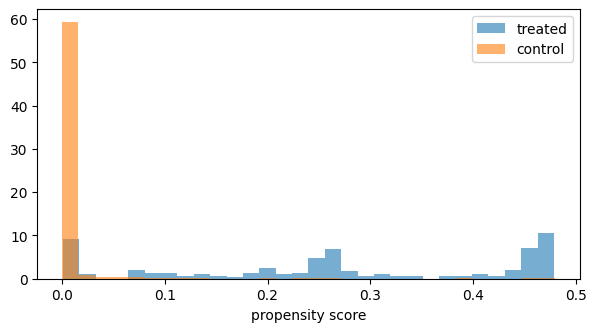

PS range: treated [0.001, 0.479], control [0.000, 0.480]
Control в диапазоне treated: 5655 из 15992-


In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(df.loc[df.treat == 1, 'ps'], bins=30, alpha=0.6, label='treated', density=True)
ax.hist(df.loc[df.treat == 0, 'ps'], bins=30, alpha=0.6, label='control', density=True)
ax.set_xlabel('propensity score')
ax.legend()
plt.show()

t_ps, c_ps = df.loc[df.treat == 1, 'ps'], df.loc[df.treat == 0, 'ps']
print(f'PS range: treated [{t_ps.min():.3f}, {t_ps.max():.3f}], '
      f'control [{c_ps.min():.3f}, {c_ps.max():.3f}]')
print(f'Control в диапазоне treated: {((c_ps>=t_ps.min())&(c_ps<=t_ps.max())).sum()} из {len(c_ps)}-')

## 3. PSM

In [ ]:
sd_logit = df['logit_ps'].std()
caliper = 0.2 * sd_logit

treat_df = df[df.treat == 1].reset_index(drop=True)
control_df = df[df.treat == 0].reset_index(drop=True)

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_df[['logit_ps']].values)
dist, idx = nn.kneighbors(treat_df[['logit_ps']].values)
dist, idx = dist.flatten(), idx.flatten()
within = dist <= caliper

psm_treat = treat_df[within].reset_index(drop=True)
psm_control = control_df.iloc[idx[within]].reset_index(drop=True)
n_unique_control = len(set(idx[within]))

print(f'Caliper: {caliper:.3f}. Заматчено: {within.sum()} из {len(treat_df)}. '
      f'Уникальных control: {n_unique_control}')

psm_matched = pd.concat([psm_treat.assign(treat=1), psm_control.assign(treat=0)], ignore_index=True)
print(smd_table(psm_matched, 'treat', covariates).round(2))

Caliper: 0.580. Заматчено: 185 из 185. Уникальных control: 131
           mean_treat  mean_control   smd
covariate                                
age             25.82         24.58  0.14
educ            10.35         10.29  0.03
black            0.84          0.84  0.00
hisp             0.06          0.03  0.13
marr             0.19          0.18  0.01
nodegree         0.71          0.70  0.02
re74          2095.57       2086.32  0.00
re75          1532.06       1287.95  0.08


In [ ]:
psm_result = paired_att(psm_treat['re78'].values, psm_control['re78'].values)
att_psm, se_psm, ci_psm = psm_result['ate'], psm_result['se'], (psm_result['ci_low'], psm_result['ci_high'])

print(f"ATT (PSM): {att_psm:,.0f}, SE {se_psm:,.0f}, "
      f"CI [{ci_psm[0]:,.0f}, {ci_psm[1]:,.0f}], p={psm_result['p_value']:.4f}")

ATT (PSM): 1,663, SE 739, CI [205, 3,121], p=0.0256


## 4. PSW (IPW)

In [ ]:
control_ps = df.loc[df.treat == 0, 'ps']
control_y = df.loc[df.treat == 0, 're78']
treat_y = df.loc[df.treat == 1, 're78']
w = (control_ps / (1 - control_ps)).values

psw_result = weighted_att(treat_y.values, control_y.values, w)
att_psw, se_psw = psw_result['ate'], psw_result['se']
ci_psw = (psw_result['ci_low'], psw_result['ci_high'])
ess = psw_result['ess']

print(f"Веса control: [{w.min():.4f}, {w.max():.4f}], ESS: {ess:.0f} из {psw_result['n_control']}")
print(f"ATT (PSW): {att_psw:,.0f}, SE (bootstrap) {se_psw:,.0f}, "
      f"CI [{ci_psw[0]:,.0f}, {ci_psw[1]:,.0f}]")

Веса control: [0.0000, 0.9228], ESS: 427 из 15992
ATT (PSW): 1,118, SE (bootstrap) 641, CI [-115, 2,357]


## 5. Сравнение

In [ ]:
benchmark = load_benchmark('benchmark.json')
history = load_results('results.csv')
naive_ate = history.loc['Naive diff-in-means (NSW+CPS)', 'ate']

rows = [
    ('Эталон', benchmark['ate'], 0, None),
    ('Наивная оценка', naive_ate, naive_ate - benchmark['ate'], None),
    ('Matching (Mahalanobis)', att_mh, att_mh - benchmark['ate'], se_mh),
    ('PSM', att_psm, att_psm - benchmark['ate'], se_psm),
    ('PSW', att_psw, att_psw - benchmark['ate'], se_psw),
]
for name, val, bias, se in rows:
    se_str = f', SE {se:,.0f}' if se is not None else ''
    print(f'{name:24s} {val:>10,.0f}   bias {bias:>9,.0f}{se_str}')

Эталон                        1,794   bias         0
Наивная оценка               -8,498   bias   -10,292
Matching (Mahalanobis)        2,089   bias       294, SE 722
PSM                           1,663   bias      -131, SE 739
PSW                           1,118   bias      -677, SE 641


PSM ближе всего к эталону (наименьшее смещение), хотя Matching (Mahalanobis)
даёт лучший баланс ковариат (SMD ≈ 0 по всем, против SMD до 0.14 у PSM) - баланс
и точечная оценка не одно и то же: лучший баланс снижает риск смещения, но не
гарантирует, что конкретная реализация окажется ближе к истине. При n=185
treated это одна выборка, а не усреднение по многим - порядок методов по
близости к эталону мог бы измениться на другой подвыборке.

По SE методы сопоставимы (614-739) и не позволяют уверенно ранжировать их по
точности - тем более что SE PSW получен бутстрэпом, а не той же параметрической
формулой, что у Matching/PSM.

In [ ]:
append_result({'ate': mh_result['ate'], 'se': mh_result['se'], 'ci_low': mh_result['ci_low'],
               'ci_high': mh_result['ci_high'], 'p_value': mh_result['p_value'],
               'n_treat': mh_result['n_pairs'], 'n_control': n_unique_mh},
              label='Matching (Mahalanobis, NN)', path='results.csv')

append_result({'ate': psm_result['ate'], 'se': psm_result['se'], 'ci_low': psm_result['ci_low'],
               'ci_high': psm_result['ci_high'], 'p_value': psm_result['p_value'],
               'n_treat': psm_result['n_pairs'], 'n_control': n_unique_control},
              label='PSM (nearest-neighbor, caliper)', path='results.csv')

append_result({'ate': psw_result['ate'], 'se': psw_result['se'], 'ci_low': psw_result['ci_low'],
               'ci_high': psw_result['ci_high'], 'p_value': psw_result['p_value'],
               'n_treat': psw_result['n_treat'], 'n_control': psw_result['n_control']},
              label='PSW (Hajek IPW, ATT weights)', path='results.csv')

,method,ate,se,ci_low,ci_high,p_value,n_treat,n_control
0,Naive diff-in-means (NSW+CPS),-8497.515625,712.020724,-9893.155036,-7101.876214,1.074814e-32,185,15992
1,"Matching (Mahalanobis, NN)",2088.650204,721.675624,664.827106,3512.473301,4.261236e-03,185,124
2,"PSM (nearest-neighbor, caliper)",1662.849182,738.834401,205.172839,3120.525525,2.559200e-02,185,131
3,"PSW (Hajek IPW, ATT weights)",1117.783535,640.877282,-115.226081,2357.479983,8.600000e-02,185,15992


## Что дальше

Часть 4 - DML на этом же датасете, сравнение с matching/PSM/PSW и эталоном.